# Phân tích Đặc trưng Thống kê (Statistical Feature EDA)

Mục đích của Notebook này là chuyển dữ liệu đa chiều (Tensor) thành dạng bảng (DataFrame) để chạy các kiểm định thống kê cơ bản. Qua đó, chúng ta sẽ quyết định cách chuẩn hóa dữ liệu tối ưu nhất cho mạng Neural.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Tải và Lấy mẫu dữ liệu (Data Sampling)

In [2]:
data_dir = Path('../era5_data') 

try:
    ds_accum = xr.open_mfdataset(str(data_dir / '*_accum.nc'), combine='by_coords')
    if 'valid_time' in ds_accum.coords: ds_accum = ds_accum.rename({'valid_time': 'time'})
    
    ds_instant = xr.open_mfdataset(str(data_dir / '*_instant.nc'), combine='by_coords')
    if 'valid_time' in ds_instant.coords: ds_instant = ds_instant.rename({'valid_time': 'time'})
    
    ds = xr.merge([ds_accum, ds_instant])
    
    # Tính toán cơ bản
    ds['tp'] = ds['tp'] * 1000.0 # ra mm
    ds['t2m_c'] = ds['t2m'] - 273.15 # ra độ C
    ds['msl_hpa'] = ds['msl'] / 100.0 # ra hPa
    
    print("Chuyển đổi sang Pandas DataFrame (Mất vài chục giây)...")
    # Để tiết kiệm RAM, ta chỉ lấy dữ liệu của tháng 8 năm 2023 làm đại diện phân tích thống kê
    ds_sample = ds[['tp', 't2m_c', 'msl_hpa', 'u10', 'v10']].sel(time='2023-08')
    
    df = ds_sample.to_dataframe().dropna().reset_index()
    print(f"Tổng số điểm dữ liệu trong tháng 8/2023: {len(df):,}")
    
    # Lấy mẫu ngẫu nhiên 50,000 điểm để vẽ biểu đồ cho nhanh
    df_sampled = df.sample(50000, random_state=42)
    
except Exception as e:
    print("Lỗi:", e)

Chuyển đổi sang Pandas DataFrame (Mất vài chục giây)...
Tổng số điểm dữ liệu trong tháng 8/2023: 1,497,672


## 2. Phân tích Phân phối (Distributions)

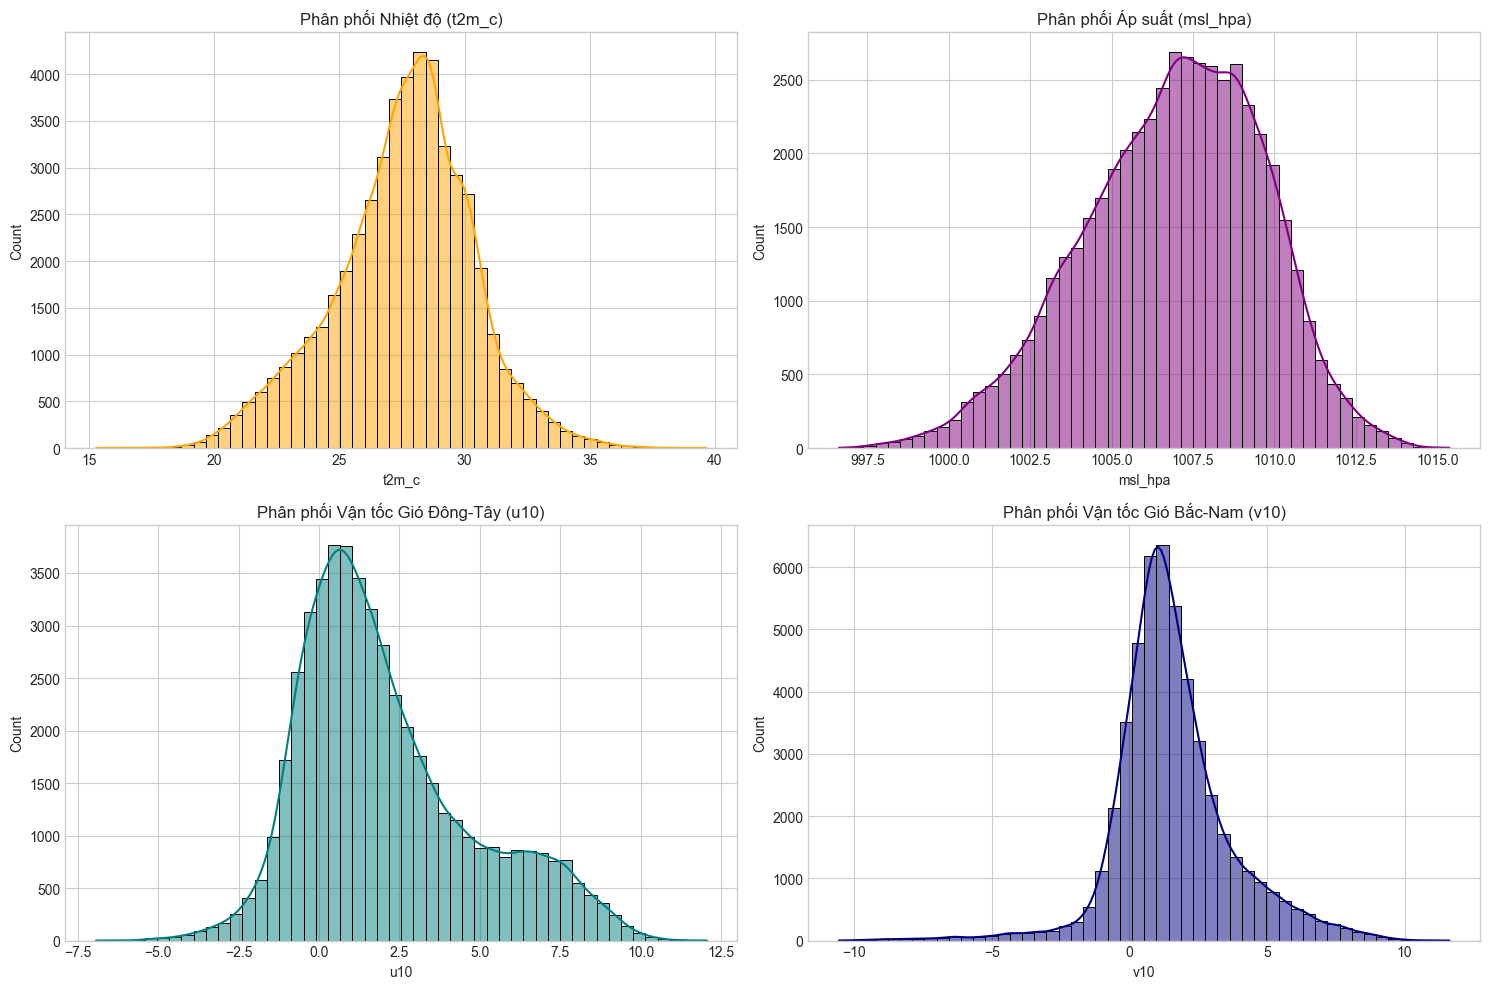

Nhận xét: Nhiệt độ, Áp suất và Gió đều tuân theo phân phối hình quả chuông (Normal-like distribution).


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Phân phối Nhiệt độ
sns.histplot(df_sampled['t2m_c'], bins=50, kde=True, ax=axes[0], color='orange')
axes[0].set_title('Phân phối Nhiệt độ (t2m_c)')

# Phân phối Áp suất
sns.histplot(df_sampled['msl_hpa'], bins=50, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Phân phối Áp suất (msl_hpa)')

# Phân phối Gió U
sns.histplot(df_sampled['u10'], bins=50, kde=True, ax=axes[2], color='teal')
axes[2].set_title('Phân phối Vận tốc Gió Đông-Tây (u10)')

# Phân phối Gió V
sns.histplot(df_sampled['v10'], bins=50, kde=True, ax=axes[3], color='navy')
axes[3].set_title('Phân phối Vận tốc Gió Bắc-Nam (v10)')

plt.tight_layout()
plt.show()

print("Nhận xét: Nhiệt độ, Áp suất và Gió đều tuân theo phân phối hình quả chuông (Normal-like distribution).")

## 3. Sự mất cân bằng của Lượng Mưa (Rainfall Imbalance)

Tỷ lệ tạnh ráo (Lượng mưa < 0.1mm): 60.36%


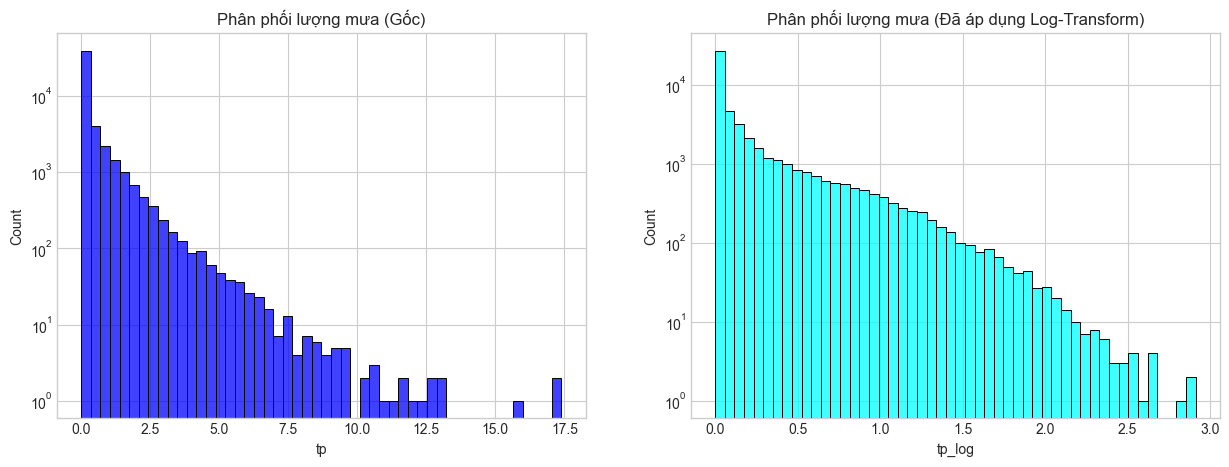

Nhận xét: Lượng mưa cực kỳ lệch. Việc áp dụng hàm Logarit giúp kéo giãn dải giá trị nhỏ, giúp AI dễ học hơn.


In [4]:
# Tỷ lệ không mưa
zero_rain = len(df_sampled[df_sampled['tp'] < 0.1])
total = len(df_sampled)
print(f"Tỷ lệ tạnh ráo (Lượng mưa < 0.1mm): {zero_rain/total*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ nguyên gốc
sns.histplot(df_sampled['tp'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Phân phối lượng mưa (Gốc)')
axes[0].set_yscale('log') # Dùng log scale ở trục Y để nhìn thấy số ít mưa to

# Biểu đồ sau khi chuyển vị Log (Log-Transform)
df_sampled['tp_log'] = np.log1p(df_sampled['tp'])
sns.histplot(df_sampled['tp_log'], bins=50, ax=axes[1], color='cyan')
axes[1].set_title('Phân phối lượng mưa (Đã áp dụng Log-Transform)')
axes[1].set_yscale('log')

plt.show()
print("Nhận xét: Lượng mưa cực kỳ lệch. Việc áp dụng hàm Logarit giúp kéo giãn dải giá trị nhỏ, giúp AI dễ học hơn.")

## 4. Phân tích Tương quan (Correlation Matrix)

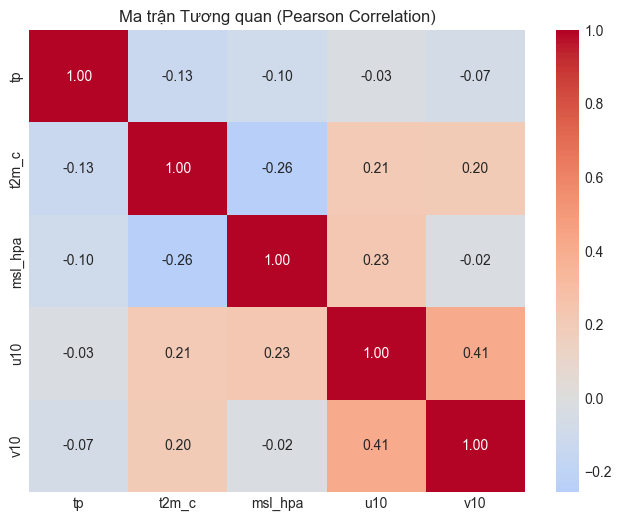

Nhận xét:
- Lượng mưa (tp) có mối tương quan nghịch với Áp suất (msl_hpa) và Nhiệt độ (t2m_c).
- Điều này chứng tỏ kiến thức vật lý: Áp suất giảm (bão/áp thấp) và nhiệt độ giảm thường mang lại mưa.


In [5]:
plt.figure(figsize=(8, 6))
corr = df_sampled[['tp', 't2m_c', 'msl_hpa', 'u10', 'v10']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Ma trận Tương quan (Pearson Correlation)')
plt.show()

print("Nhận xét:\n- Lượng mưa (tp) có mối tương quan nghịch với Áp suất (msl_hpa) và Nhiệt độ (t2m_c).\n- Điều này chứng tỏ kiến thức vật lý: Áp suất giảm (bão/áp thấp) và nhiệt độ giảm thường mang lại mưa.")